In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [11]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
remote: Total 3839 (delta 9), reused 385 (delta 0), pack-reused 3439 (from 1)
Receiving objects: 100% (3839/3839), 100.58 MiB | 45.51 MiB/s, done.
Resolving deltas: 100% (10/10), done.


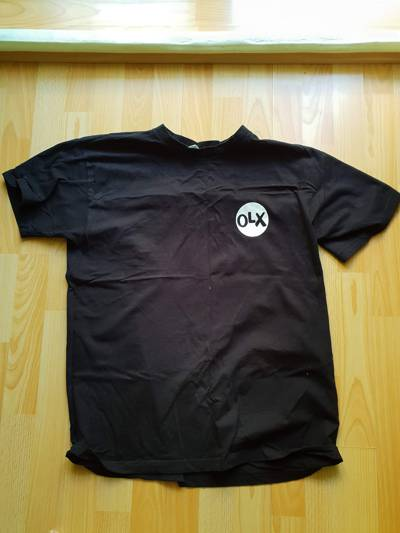

In [12]:
path = "./clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
fullpath = f"{path}/{name}"
load_img(fullpath)

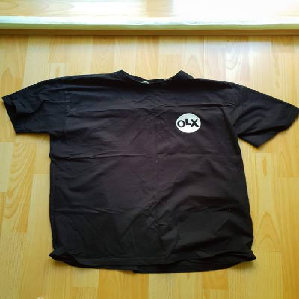

In [18]:
x = load_img(fullpath, target_size=(299, 299))
x

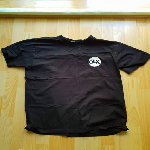

In [14]:
img = load_img(fullpath, target_size=(150, 150))
img

In [15]:
x = np.array(img)
x.shape

(150, 150, 3)

In [19]:
X = np.array(x)
X = np.array([X])
X.shape

(1, 299, 299, 3)

In [20]:
model = Xception(weights="imagenet", input_shape=(299, 299, 3))
img_p = preprocess_input(X)
pred = model.predict(img_p)
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n03595614', 'jersey', np.float32(0.68196356)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038139977)),
  ('n04370456', 'sweatshirt', np.float32(0.034324735)),
  ('n03710637', 'maillot', np.float32(0.011354207)),
  ('n04525038', 'velvet', np.float32(0.0018453562))]]

## Transfer Learning

In [21]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds= train_gen.flow_from_directory(
    "./clothing-dataset-small/train",
    target_size = (150, 150),
    batch_size = 32
)

Found 3068 images belonging to 10 classes.


In [22]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [23]:
X,y = next(train_ds)

In [24]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    "./clothing-dataset-small/validation",
    target_size = (150, 150),
    batch_size = 32
)

Found 341 images belonging to 10 classes.


In [25]:
base_model = Xception(
    weights="imagenet",
    include_top = False,
    input_shape = (150, 150, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))
base = base_model(inputs, training=False)
vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(10) (vectors)

model = keras.Model(inputs, outputs)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)
model.compile(
    optimizer = optimizer,
    loss = loss,
    metrics = ["accuracy"]
)

In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 56s 398ms/step - accuracy: 0.6744 - loss: 1.2566 - val_accuracy: 0.7537 - val_loss: 1.0250
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8224 - loss: 0.5734 - val_accuracy: 0.7742 - val_loss: 0.8227
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8706 - loss: 0.4001 - val_accuracy: 0.7683 - val_loss: 1.0194
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9084 - loss: 0.2558 - val_accuracy: 0.8006 - val_loss: 0.8821
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9319 - loss: 0.1916 - val_accuracy: 0.7947 - val_loss: 0.8982
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9566 - loss: 0.1196 - val_accuracy: 0.7889 - val_loss: 0.9980
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9651 - loss: 0.0942 - val_accuracy: 0.8065 - val_loss: 1.0595
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9860 - loss: 0.0561 - val_accuracy: 0.8299 -

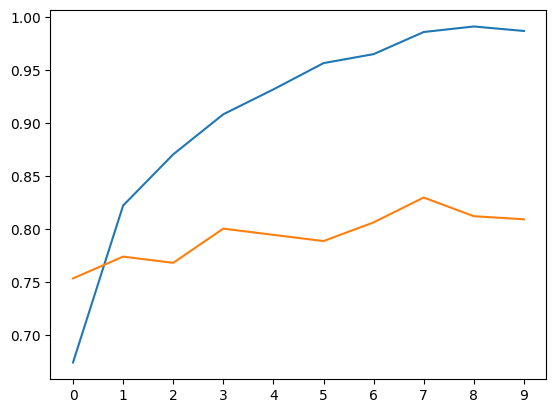

In [ ]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xticks(np.arange(10))
plt.show()

In [ ]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights = "imagenet",
        include_top = False,
        input_shape = (150, 150, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(150, 150, 3))

    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer = optimizer,
        loss = loss,
        metrics = ["accuracy"]
    )

    return model

In [ ]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(lr)
    history = model.fit(train_ds, epochs=10, validation_data = val_ds)
    scores[lr] = history

    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 209ms/step - accuracy: 0.3677 - loss: 1.8882 - val_accuracy: 0.5191 - val_loss: 1.5622
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5610 - loss: 1.3775 - val_accuracy: 0.6276 - val_loss: 1.2365
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.6431 - loss: 1.1462 - val_accuracy: 0.6745 - val_loss: 1.0709
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.6809 - loss: 1.0089 - val_accuracy: 0.7126 - val_loss: 0.9648
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7063 - loss: 0.9183 - val_accuracy: 0.7361 - val_loss: 0.8924
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7229 - loss: 0.8499 - val_accuracy: 0.7537 - val_loss: 0.8423
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7383 - loss: 0.7959 - val_accuracy: 0.7566 - val_loss: 0.8012
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7503 - loss: 0.7529 - val_accuracy: 0

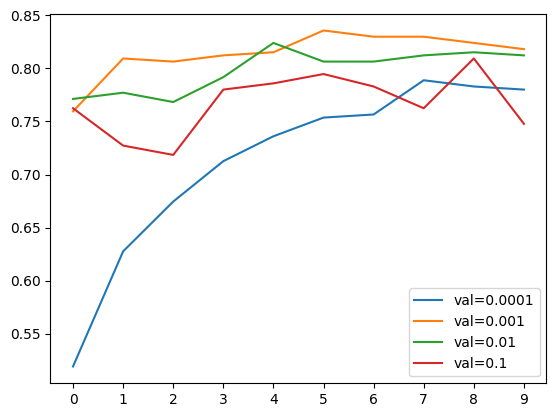

In [ ]:
for lr, hist in scores.items():
    # plt.plot(hist.history["accuracy"], label=("train=%s" % lr))
    plt.plot(hist.history["val_accuracy"], label=("val=%s" % lr))

plt.legend()
plt.xticks(np.arange(10))
plt.show()

In [29]:
learning_rate = 0.001

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5",
    save_best_only = True,
    monitor = "val_accuracy",
    mode = "max"
)

In [ ]:
model  = make_model(learning_rate)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data = val_ds,
    callbacks = [checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5015 - loss: 1.4507

96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 206ms/step - accuracy: 0.6258 - loss: 1.0923 - val_accuracy: 0.7859 - val_loss: 0.7184
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7786 - loss: 0.6283

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7784 - loss: 0.6264 - val_accuracy: 0.7947 - val_loss: 0.6299
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8329 - loss: 0.4917

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8328 - loss: 0.5022 - val_accuracy: 0.8299 - val_loss: 0.5771
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8719 - loss: 0.4258 - val_accuracy: 0.8270 - val_loss: 0.5459
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8902 - loss: 0.3710 - val_accuracy: 0.8299 - val_loss: 0.5329
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9150 - loss: 0.3061

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9048 - loss: 0.3241 - val_accuracy: 0.8328 - val_loss: 0.5230
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9283 - loss: 0.2839 - val_accuracy: 0.8240 - val_loss: 0.5409
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9280 - loss: 0.2611 - val_accuracy: 0.8270 - val_loss: 0.5283
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9462 - loss: 0.2292 - val_accuracy: 0.8328 - val_loss: 0.5335
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9613 - loss: 0.1903

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9524 - loss: 0.2086 - val_accuracy: 0.8416 - val_loss: 0.5260


In [ ]:
def make_model_v1(learning_rate, inner_neuron):

    base_model = Xception(
        weights = "imagenet",
        include_top = False,
        input_shape = (150, 150, 3)
    )

    base_model.trainiable = False

    inputs = keras.Input(shape=(150, 150, 3))

    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner_layer = keras.layers.Dense(100)(vectors)
    outputs = keras.layers.Dense(10)(inner_layer)

    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer,
        loss = loss,
        metrics = ["accuracy"]
    )

    return model

In [ ]:
learning_rate = 0.001
score = {}

checkpoint = keras.callbacks.ModelCheckpoint(
    "xception_v2_{epoch:02d}_{val_accuracy:.3f}.h5",
    save_best_only = True,
    monitor = "val_accuracy",
    mode = max
)

for dn in [20, 50, 100, 150, 200]:
    model = make_model_v1(learning_rate, dn)
    history = model.fit(
        train_ds,
        epochs = 10,
        validation_data = val_ds,
        callbacks = [checkpoint]
    )
    score[dn] = history

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.6388 - loss: 1.1741

96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 754ms/step - accuracy: 0.7507 - loss: 0.8183 - val_accuracy: 0.7625 - val_loss: 1.1655
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.8788 - loss: 0.3728

96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.8862 - loss: 0.3564 - val_accuracy: 0.8299 - val_loss: 1.0621
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9318 - loss: 0.2156

96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.9224 - loss: 0.2446 - val_accuracy: 0.8680 - val_loss: 0.5220
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.9557 - loss: 0.1349 - val_accuracy: 0.8563 - val_loss: 0.6697
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.9527 - loss: 0.1509 - val_accuracy: 0.7742 - val_loss: 1.5450
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 216ms/step - accuracy: 0.9505 - loss: 0.1747 - val_accuracy: 0.8504 - val_loss: 0.6576
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.9589 - loss: 0.1335 - val_accuracy: 0.8387 - val_loss: 0.7127
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.9703 - loss: 0.1003 - val_accuracy: 0.8534 - val_loss: 0.5059
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.9785 - loss: 0.0707 - val_accuracy: 0.8475 - val_loss: 0.6446
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9681 - loss: 0.0950 - val_accuracy: 0.86

96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.9606 - loss: 0.1129 - val_accuracy: 0.8710 - val_loss: 0.5068
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9827 - loss: 0.0672 - val_accuracy: 0.7977 - val_loss: 0.9694
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.9729 - loss: 0.0920 - val_accuracy: 0.8504 - val_loss: 0.6235
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.9720 - loss: 0.0902 - val_accuracy: 0.7243 - val_loss: 1.6174
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 91s 515ms/step - accuracy: 0.7331 - loss: 0.8616 - val_accuracy: 0.7566 - val_loss: 0.9249
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.8752 - loss: 0.3962 - val_accuracy: 0.7889 - val_loss: 0.9767
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.9205 - loss: 0.2769 - val_accuracy: 0.7361 - val_loss: 1.2370
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.9319 - loss: 0.2239 - val_accuracy: 0.82

96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 281ms/step - accuracy: 0.9668 - loss: 0.1132 - val_accuracy: 0.8827 - val_loss: 0.5183
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9710 - loss: 0.0958 - val_accuracy: 0.8651 - val_loss: 0.5691
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.9707 - loss: 0.1036 - val_accuracy: 0.8504 - val_loss: 0.6230
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9808 - loss: 0.0657 - val_accuracy: 0.7713 - val_loss: 1.2194


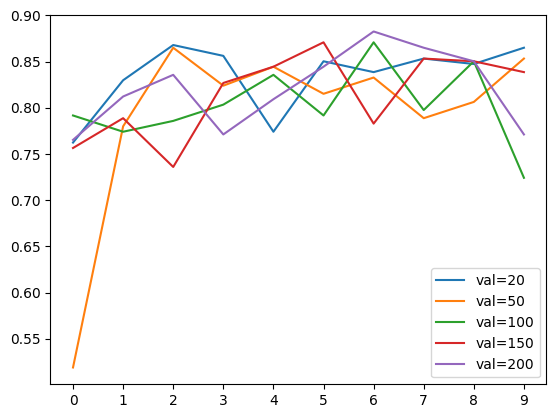

In [ ]:
for neuron, history in score.items():
    # plt.plot(history.history["accuracy"], label=("train=%s" %neuron))
    plt.plot(history.history["val_accuracy"], label=("val=%s"%neuron))
plt.xticks(np.arange(10))
plt.legend()
plt.show()

In [28]:
inner_neuron = 100

In [26]:
def make_model_v3(learning_rate, layer_neuron, droprate=0.5):

    base_model = Xception(
        weights = "imagenet",
        include_top = False,
        input_shape = (150, 150, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape = (150, 150, 3))
    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner_layer = keras.layers.Dense(layer_neuron, activation="relu")(vectors)
    dropout = keras.layers.Dropout(droprate)(inner_layer)
    outputs = keras.layers.Dense(10)(dropout)

    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer,
        loss = loss,
        metrics = ["accuracy"]
    )

    return model

In [31]:
score = {}

for dp in [0.1, 0.2, 0.3, 0.4, 0.5]:
    checkpoint = keras.callbacks.ModelCheckpoint(
    f"xceptions_v3_{dp}_{{epoch:02d}}_{{val_accuracy:.3f}}.h5",
    save_best_only = True,
    monitor = "val_accuracy",
    mode = "max"
)

    model = make_model_v3(learning_rate, inner_neuron)
    history = model.fit(
        train_ds,
        epochs = 10,
        validation_data = val_ds,
        callbacks = [checkpoint]
    )

    score[dp] = history

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4796 - loss: 1.5700

96/96 ━━━━━━━━━━━━━━━━━━━━ 31s 236ms/step - accuracy: 0.5834 - loss: 1.2478 - val_accuracy: 0.7771 - val_loss: 0.7531
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7295 - loss: 0.8226

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.7324 - loss: 0.8078 - val_accuracy: 0.8094 - val_loss: 0.6346
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7693 - loss: 0.6841

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.7686 - loss: 0.6833 - val_accuracy: 0.8182 - val_loss: 0.5878
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8051 - loss: 0.5582 - val_accuracy: 0.8152 - val_loss: 0.5866
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.8334 - loss: 0.4861 - val_accuracy: 0.8152 - val_loss: 0.5713
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8647 - loss: 0.4069

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.8520 - loss: 0.4302 - val_accuracy: 0.8240 - val_loss: 0.5282
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8634 - loss: 0.3882 - val_accuracy: 0.8182 - val_loss: 0.5613
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8830 - loss: 0.3411 - val_accuracy: 0.8065 - val_loss: 0.5689
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8875 - loss: 0.3197 - val_accuracy: 0.8240 - val_loss: 0.5274
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9048 - loss: 0.2834 - val_accuracy: 0.8094 - val_loss: 0.5525
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4750 - loss: 1.5778

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.7168 - loss: 0.8212 - val_accuracy: 0.7977 - val_loss: 0.6155
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.7725 - loss: 0.6754 - val_accuracy: 0.7859 - val_loss: 0.6069
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7841 - loss: 0.5894

96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.7907 - loss: 0.5731 - val_accuracy: 0.8035 - val_loss: 0.5619
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8162 - loss: 0.5032 - val_accuracy: 0.7977 - val_loss: 0.5562
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8468 - loss: 0.4428 - val_accuracy: 0.8035 - val_loss: 0.5532
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8578 - loss: 0.4063

96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8592 - loss: 0.4067 - val_accuracy: 0.8123 - val_loss: 0.5161
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8757 - loss: 0.3592

96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8703 - loss: 0.3668 - val_accuracy: 0.8182 - val_loss: 0.5226
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8980 - loss: 0.3038

96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.8963 - loss: 0.3117 - val_accuracy: 0.8240 - val_loss: 0.5547
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9071 - loss: 0.2795 - val_accuracy: 0.8094 - val_loss: 0.5840


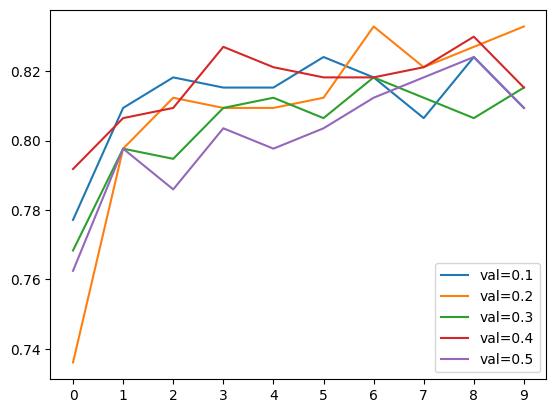

In [34]:
for dp, history in score.items():
    # plt.plot(history.history["accuracy"], label = ("train=%s" % dp))
    plt.plot(history.history["val_accuracy"], label = ("val=%s" % dp))

plt.legend()
plt.xticks(np.arange(10))
plt.show()

In [35]:
drop_rate = 0.2

## Data Augmentation


In [74]:
train_ag_gen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    # shear_range = 20,
    # zoom_range = 0.2,
    horizontal_flip = True
)

ag_train_ds = train_ag_gen.flow_from_directory(
    "./clothing-dataset-small/train",
    target_size = (150, 150),
    batch_size = 32
)

Found 3068 images belonging to 10 classes.


In [80]:
def make_model_v4(input_size, learning_rate, neuron, droprate):

    base_model = Xception(
        weights = "imagenet",
        include_top = False,
        input_shape = (input_size, input_size, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape = (input_size, input_size, 3))
    base = base_model(inputs, training = False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(neuron, activation = "relu")(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits = True)

    model.compile(
        optimizer = optimizer,
        loss = loss,
        metrics = ["accuracy"]
    )

    return model


In [75]:
model = make_model_v4(learning_rate, inner_neuron, drop_rate)

checkpoint = keras.callbacks.ModelCheckpoint(
    "xceptions_v4_{epoch:02d}_{val_accuracy:.3f}.h5",
    save_best_only = True,
    monitor = "val_accuracy",
    mode = "max"
)

history = model.fit(ag_train_ds,
                    epochs=10,
                    validation_data = val_ds
                    # callbacks = [checkpoint]

            )

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - accuracy: 0.6304 - loss: 1.0940 - val_accuracy: 0.7683 - val_loss: 0.7042
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.7728 - loss: 0.6608 - val_accuracy: 0.8006 - val_loss: 0.6162
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8198 - loss: 0.5249 - val_accuracy: 0.7947 - val_loss: 0.5967
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8602 - loss: 0.4146 - val_accuracy: 0.8006 - val_loss: 0.5791
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8719 - loss: 0.3588 - val_accuracy: 0.8270 - val_loss: 0.5650
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8993 - loss: 0.3010 - val_accuracy: 0.8152 - val_loss: 0.5804
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9156 - loss: 0.2488 - val_accuracy: 0.8152 - val_loss: 0.5864
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9335 - loss: 0.2109 - val_accuracy: 0.7947 

In [77]:
input_size = 299

In [78]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [79]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [81]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model_v4(
    input_size,
    learning_rate,
    size,
    droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5438 - loss: 1.4128

96/96 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6770 - loss: 1.0156 - val_accuracy: 0.8211 - val_loss: 0.5341
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8216 - loss: 0.5644

96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 886ms/step - accuracy: 0.8272 - loss: 0.5372 - val_accuracy: 0.8416 - val_loss: 0.4417
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.8525 - loss: 0.4313

96/96 ━━━━━━━━━━━━━━━━━━━━ 87s 907ms/step - accuracy: 0.8527 - loss: 0.4342 - val_accuracy: 0.8768 - val_loss: 0.4018
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 886ms/step - accuracy: 0.8651 - loss: 0.3994 - val_accuracy: 0.8504 - val_loss: 0.3736
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 869ms/step - accuracy: 0.8716 - loss: 0.3644 - val_accuracy: 0.8563 - val_loss: 0.3892
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 881ms/step - accuracy: 0.8882 - loss: 0.3237 - val_accuracy: 0.8768 - val_loss: 0.3671
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 889ms/step - accuracy: 0.8977 - loss: 0.2954 - val_accuracy: 0.8680 - val_loss: 0.3798
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9170 - loss: 0.2543

96/96 ━━━━━━━━━━━━━━━━━━━━ 86s 892ms/step - accuracy: 0.9016 - loss: 0.2799 - val_accuracy: 0.8856 - val_loss: 0.3729
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 873ms/step - accuracy: 0.9081 - loss: 0.2726 - val_accuracy: 0.8798 - val_loss: 0.3514
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.9185 - loss: 0.2497

96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 889ms/step - accuracy: 0.9166 - loss: 0.2488 - val_accuracy: 0.8944 - val_loss: 0.3345
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 85s 890ms/step - accuracy: 0.9156 - loss: 0.2411 - val_accuracy: 0.8680 - val_loss: 0.3642
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 86s 894ms/step - accuracy: 0.9172 - loss: 0.2296 - val_accuracy: 0.8768 - val_loss: 0.3496
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 890ms/step - accuracy: 0.9345 - loss: 0.2002 - val_accuracy: 0.8886 - val_loss: 0.3336
Epoch 14/50
34/96 ━━━━━━━━━━━━━━━━━━━━ 50s 810ms/step - accuracy: 0.9326 - loss: 0.1966

KeyboardInterrupt: 